In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.pyfunc
import mlflow.sklearn
import sklearn
import cloudpickle
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from mlflow.models.signature import infer_signature
from mlflow.utils.environment import _mlflow_conda_env

In [10]:
df = pd.read_csv('data/arabica_data_cleaned.csv', index_col=0)
df.head()

,Species,Owner,Country.of.Origin,Farm.Name,Lot.Number,Mill,ICO.Number,Company,Altitude,Region,...,Color,Category.Two.Defects,Expiration,Certification.Body,Certification.Address,Certification.Contact,unit_of_measurement,altitude_low_meters,altitude_high_meters,altitude_mean_meters
1,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,0,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
2,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,1,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0
3,Arabica,grounds for health admin,Guatemala,"san marcos barrancas ""san cristobal cuch",NaN,NaN,NaN,NaN,1600 - 1800 m,NaN,...,NaN,0,"May 31st, 2011",Specialty Coffee Association,36d0d00a3724338ba7937c52a378d085f2172daa,0878a7d4b9d35ddbf0fe2ce69a2062cceb45a660,m,1600.0,1800.0,1700.0
4,Arabica,yidnekachew dabessa,Ethiopia,yidnekachew dabessa coffee plantation,NaN,wolensu,NaN,yidnekachew debessa coffee plantation,1800-2200,oromia,...,Green,2,"March 25th, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1800.0,2200.0,2000.0
5,Arabica,metad plc,Ethiopia,metad plc,NaN,metad plc,2014/2015,metad agricultural developmet plc,1950-2200,guji-hambela,...,Green,2,"April 3rd, 2016",METAD Agricultural Development plc,309fcf77415a3661ae83e027f7e5f05dad786e44,19fef5a731de2db57d16da10287413f5f99bc2dd,m,1950.0,2200.0,2075.0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1311 entries, 1 to 1312
Data columns (total 43 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Species                1311 non-null   object 
 1   Owner                  1304 non-null   object 
 2   Country.of.Origin      1310 non-null   object 
 3   Farm.Name              955 non-null    object 
 4   Lot.Number             270 non-null    object 
 5   Mill                   1001 non-null   object 
 6   ICO.Number             1163 non-null   object 
 7   Company                1102 non-null   object 
 8   Altitude               1088 non-null   object 
 9   Region                 1254 non-null   object 
 10  Producer               1081 non-null   object 
 11  Number.of.Bags         1311 non-null   int64  
 12  Bag.Weight             1311 non-null   object 
 13  In.Country.Partner     1311 non-null   object 
 14  Harvest.Year           1264 non-null   object 
 15  Grading.D

In [12]:
# Select the 10 standard SCA cupping attributes as features
SENSORY_COLS = [
    'Aroma', 'Flavor', 'Aftertaste', 'Acidity',
    'Body', 'Balance', 'Uniformity', 'Clean.Cup',
    'Sweetness', 'Cupper.Points'
]

data = df[SENSORY_COLS + ['Total.Cup.Points']].copy()

# Replace dots with underscores for MLflow compatibility
data.columns = [c.replace('.', '_') for c in data.columns]
data.head()

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,Total_Cup_Points
1,8.67,8.83,8.67,8.75,8.50,8.42,10.0,10.0,10.0,8.75,90.58
2,8.75,8.67,8.50,8.58,8.42,8.42,10.0,10.0,10.0,8.58,89.92
3,8.42,8.50,8.42,8.42,8.33,8.42,10.0,10.0,10.0,9.25,89.75
4,8.17,8.58,8.42,8.42,8.50,8.25,10.0,10.0,10.0,8.67,89.00
5,8.25,8.50,8.25,8.50,8.42,8.33,10.0,10.0,10.0,8.58,88.83


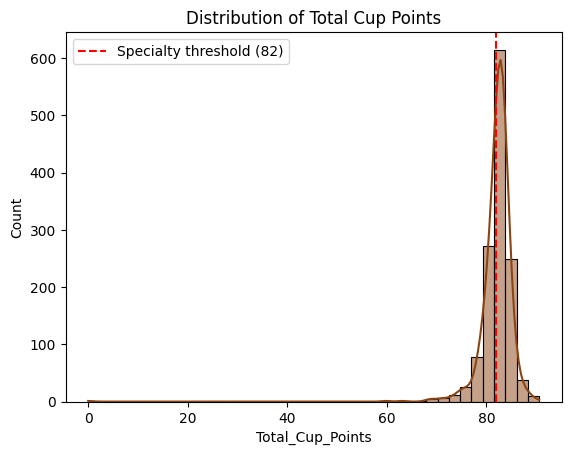

In [13]:
sns.histplot(data['Total_Cup_Points'], bins=40, kde=True, color='saddlebrown')
plt.axvline(82, color='red', linestyle='--', label='Specialty threshold (82)')
plt.title('Distribution of Total Cup Points')
plt.legend()
plt.show()

Scores are concentrated between 78 and 87. The SCA defines specialty-grade coffee as Total Cup Points >= 82.

In [14]:
# Define high quality as Total Cup Points >= 82 (SCA specialty threshold)
high_quality = (data['Total_Cup_Points'] >= 82).astype(int)
data['high_quality'] = high_quality
data.drop(columns=['Total_Cup_Points'], inplace=True)

In [15]:
data.isna().any()

Aroma            False
Flavor           False
Aftertaste       False
Acidity          False
Body             False
Balance          False
Uniformity       False
Clean_Cup        False
Sweetness        False
Cupper_Points    False
high_quality     False
dtype: bool

In [16]:
data.dropna(inplace=True)

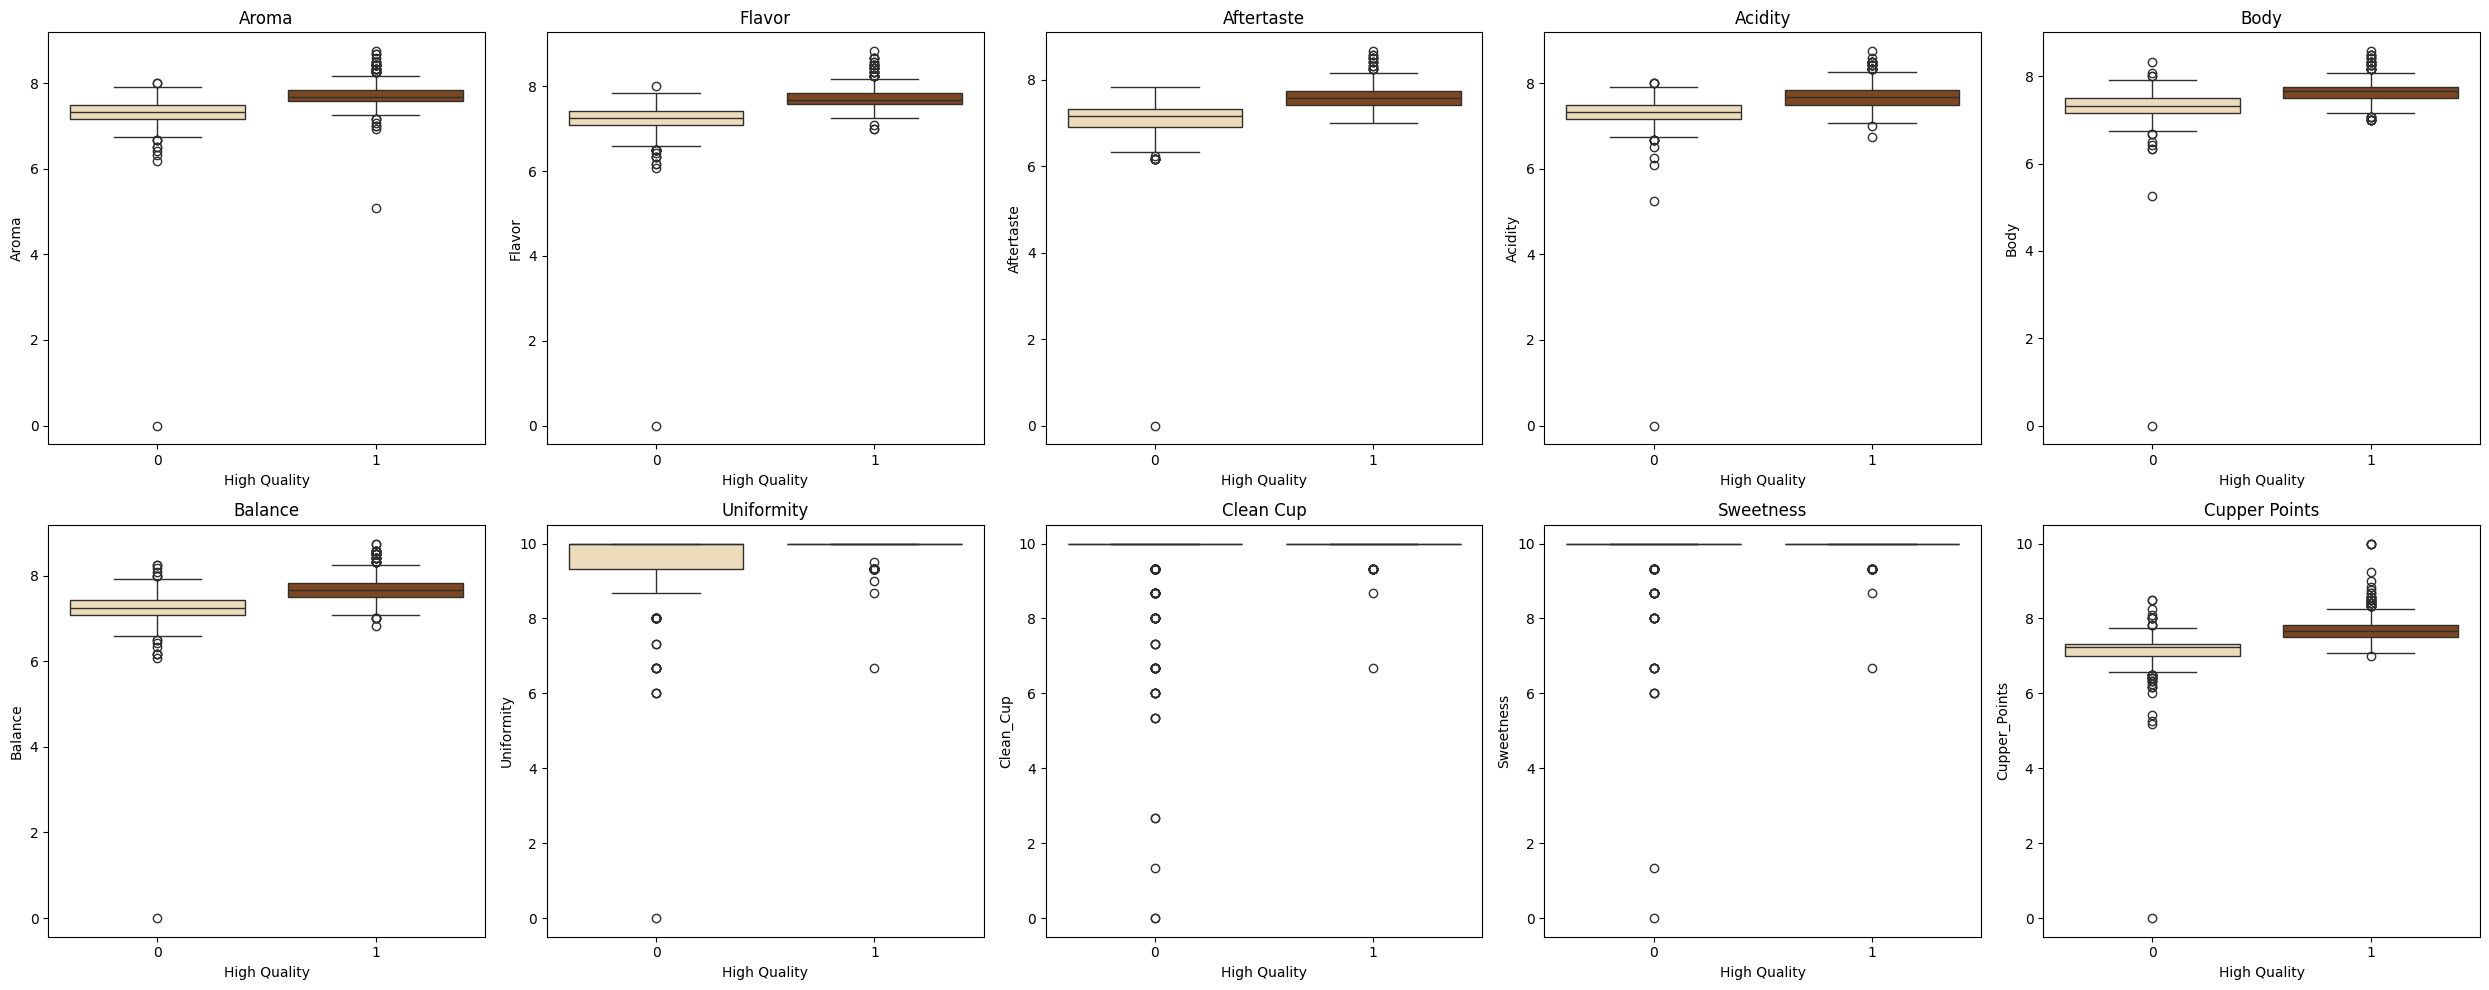

In [17]:
feature_cols = [c for c in data.columns if c != 'high_quality']

dims = (2, 5)
f, axes = plt.subplots(dims[0], dims[1], figsize=(25, 10))

for idx, col in enumerate(feature_cols):
    ax = axes[idx // dims[1]][idx % dims[1]]
    sns.boxplot(x=high_quality, y=data[col], ax=ax,
                palette={'0': 'wheat', '1': 'saddlebrown'})
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('High Quality')

plt.tight_layout()
plt.show()

Flavor, Balance, and Cupper Points show the clearest separation between standard and specialty grades. These are likely to be strong predictors in the model.

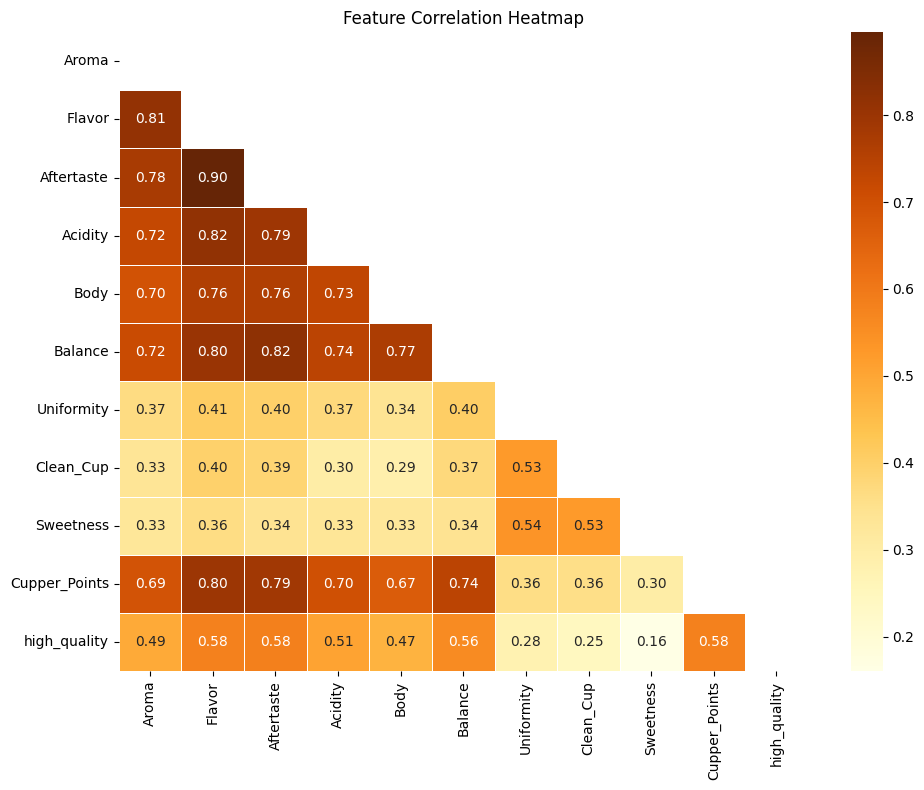

In [18]:
# Correlation heatmap to check for multicollinearity among sensory features
fig, ax = plt.subplots(figsize=(10, 8))
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='YlOrBr', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [19]:
X = data.drop(columns=['high_quality'])
y = data['high_quality']

# Split out the training data
X_train, X_rem, y_train, y_rem = train_test_split(X, y, train_size=0.6, random_state=123)

# Split the remaining data equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_rem, y_rem, test_size=0.5, random_state=123)

## Build a Baseline Model

This task suits a random forest classifier since the output is binary and there may be interactions between sensory variables.

The following code builds a classifier using scikit-learn and uses MLflow to track model accuracy and save the model for later use.

In [20]:
# The predict method of RandomForestClassifier returns a binary classification (0 or 1).
# SklearnModelWrapper uses predict_proba to return the probability of belonging to each class.
class SklearnModelWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, model):
        self.model = model

    def predict(self, context, model_input):
        return self.model.predict_proba(model_input)[:, 1]


with mlflow.start_run(run_name='untuned_random_forest'):
    n_estimators = 100
    model = RandomForestClassifier(n_estimators=n_estimators, random_state=np.random.RandomState(123))
    model.fit(X_train, y_train)

    # predict_proba returns [prob_negative, prob_positive], slice with [:, 1]
    predictions_test = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, predictions_test)

    mlflow.log_param('n_estimators', n_estimators)
    mlflow.log_metric('auc', auc_score)

    wrappedModel = SklearnModelWrapper(model)
    signature = infer_signature(X_train, wrappedModel.predict(None, X_train))

    conda_env = _mlflow_conda_env(
        additional_conda_deps=None,
        additional_pip_deps=["cloudpickle=={}".format(cloudpickle.__version__),
                             "scikit-learn=={}".format(sklearn.__version__)],
        additional_conda_channels=None,
    )
    mlflow.pyfunc.log_model('random_forest_model',
                            python_model=wrappedModel,
                            conda_env=conda_env,
                            signature=signature)

/Users/ankitkumarsahoo/Documents/MLOps Labs/MLFlows Lab 2/coffee_env/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:186: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/03/12 20:56:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/12 20:56:46 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


In [21]:
feature_importances = pd.DataFrame(model.feature_importances_,
                                   index=X_train.columns.tolist(),
                                   columns=['importance'])
feature_importances.sort_values('importance', ascending=False)

,importance
Cupper_Points,0.292815
Balance,0.225553
Flavor,0.124849
Aftertaste,0.106391
Aroma,0.068784
Body,0.052450
Acidity,0.045121
Clean_Cup,0.041546
Uniformity,0.034578
Sweetness,0.007914


Cupper Points, Flavor, and Balance are the top predictors of specialty-grade coffee, consistent with the box plot observations above.

              precision    recall  f1-score   support

    Standard       0.95      0.86      0.91        96
   Specialty       0.93      0.98      0.95       167

    accuracy                           0.94       263
   macro avg       0.94      0.92      0.93       263
weighted avg       0.94      0.94      0.93       263



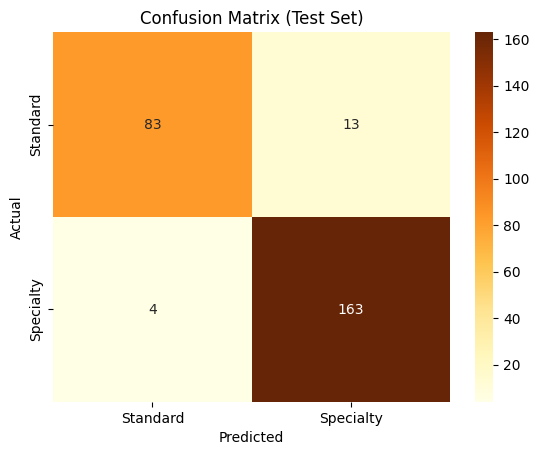

In [22]:
# Confusion matrix and classification report on the test set
test_preds_binary = (predictions_test >= 0.5).astype(int)

print(classification_report(y_test, test_preds_binary, target_names=['Standard', 'Specialty']))

cm = confusion_matrix(y_test, test_preds_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=['Standard', 'Specialty'],
            yticklabels=['Standard', 'Specialty'])
plt.title('Confusion Matrix (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Register the Model in MLflow Model Registry

By registering the model, you can easily reference and manage versions from anywhere.

In [23]:
run_id = mlflow.search_runs(filter_string='tags.mlflow.runName = "untuned_random_forest"').iloc[0].run_id
run_id

'eb36a32ac2574e1a9c2021dea51469ac'

In [24]:
model_name = 'coffee_quality'
model_version = mlflow.register_model(f'runs:/{run_id}/random_forest_model', model_name)

# Registering the model takes a few seconds, so add a small delay
time.sleep(5)

Registered model 'coffee_quality' already exists. Creating a new version of this model...
2026/03/12 20:56:46 WARNING mlflow.tracking._model_registry.fluent: Run with id eb36a32ac2574e1a9c2021dea51469ac has no artifacts at artifact path 'random_forest_model', registering model based on models:/m-56b0a28d29724e4592f3ce0b991a7795 instead
Created version '7' of model 'coffee_quality'.


In [25]:
from mlflow.tracking import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
    name=model_name,
    version=model_version.version,
    stage='Production',
)

<ModelVersion: aliases=[], creation_timestamp=1773363406718, current_stage='Production', deployment_job_state=None, description=None, last_updated_timestamp=1773363411748, metrics=None, model_id=None, name='coffee_quality', params=None, run_id='eb36a32ac2574e1a9c2021dea51469ac', run_link=None, source='models:/m-56b0a28d29724e4592f3ce0b991a7795', status='READY', status_message=None, tags={}, user_id=None, version=7, workspace='default'>

The model version is now in stage "Production". You can refer to it using the path `models:/coffee_quality/production`.

In [26]:
model = mlflow.pyfunc.load_model(f'models:/{model_name}/production')

# Sanity-check: this should match the AUC logged by MLflow
print(f'AUC: {roc_auc_score(y_test, model.predict(X_test))}')

AUC: 0.9839695608782435


In [27]:
# Run in terminal (not here) to avoid blocking the notebook:
# mlflow ui

## Batch Inference

Evaluate the production model on new data to generate predictions at scale.

In [28]:
batch_probs = model.predict(X_test)

results = X_test.copy()
results['actual_high_quality']   = y_test.values
results['predicted_probability'] = batch_probs
results['predicted_class']       = (batch_probs >= 0.5).astype(int)

results.head(10)

,Aroma,Flavor,Aftertaste,Acidity,Body,Balance,Uniformity,Clean_Cup,Sweetness,Cupper_Points,actual_high_quality,predicted_probability,predicted_class
337,7.75,7.75,7.50,7.83,7.58,7.58,10.00,10.00,10.0,7.58,1,1.00,1
1258,7.08,6.92,6.83,6.67,7.58,7.42,8.67,9.33,10.0,6.75,0,0.00,0
596,7.67,7.42,7.42,7.58,7.33,7.67,10.00,10.00,10.0,7.67,1,0.99,1
201,7.42,7.67,7.83,7.75,7.92,7.83,10.00,10.00,10.0,7.83,1,0.99,1
729,7.67,7.58,7.50,7.58,7.50,7.50,10.00,10.00,10.0,7.00,1,0.76,1
204,7.83,7.83,7.50,7.92,7.58,7.75,10.00,10.00,10.0,7.83,1,1.00,1
1312,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0,0.00,0
954,7.25,7.33,7.33,7.33,7.33,7.42,10.00,10.00,10.0,7.33,0,0.03,0
197,7.83,7.83,7.58,7.75,7.75,7.75,10.00,10.00,10.0,7.75,1,1.00,1
783,7.42,7.33,7.42,7.42,7.50,7.58,10.00,10.00,10.0,7.42,1,0.58,1


In [29]:
model_version.run_id

'eb36a32ac2574e1a9c2021dea51469ac'

In [30]:
# Serve the model using MLflow Model Serving
# Run the following in terminal after activating the virtual environment:
# mlflow models serve --env-manager=local -m models:/coffee_quality/production -h 0.0.0.0 -p 5001

In [31]:
import requests
import json

url = 'http://localhost:5001/invocations'

datads_dict = {'dataframe_split': X_test.to_dict(orient='split')}

response = requests.post(url, json=datads_dict)
predictions = response.json()

print(predictions)

{'predictions': [1.0, 0.0, 0.99, 0.99, 0.76, 1.0, 0.0, 0.03, 1.0, 0.58, 0.64, 1.0, 0.99, 0.99, 0.99, 1.0, 0.69, 0.22, 1.0, 0.41, 0.0, 0.85, 0.38, 0.0, 0.82, 0.99, 0.35, 0.82, 1.0, 0.82, 1.0, 1.0, 0.32, 0.96, 0.82, 0.93, 0.68, 0.74, 1.0, 0.72, 0.99, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.85, 0.87, 0.65, 0.0, 0.59, 0.0, 0.0, 0.99, 0.0, 0.01, 0.98, 0.99, 0.01, 0.9, 1.0, 1.0, 0.96, 0.7, 0.78, 1.0, 0.03, 0.01, 1.0, 0.9, 0.31, 0.92, 0.0, 0.16, 0.86, 0.73, 0.22, 0.94, 1.0, 0.01, 1.0, 0.95, 1.0, 1.0, 1.0, 0.01, 0.01, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.93, 1.0, 0.99, 0.24, 0.27, 0.91, 1.0, 0.0, 0.02, 1.0, 1.0, 0.79, 1.0, 1.0, 1.0, 1.0, 0.99, 0.98, 1.0, 0.79, 0.0, 1.0, 0.03, 0.22, 1.0, 1.0, 0.0, 0.94, 0.36, 0.57, 0.57, 1.0, 0.42, 0.0, 1.0, 1.0, 1.0, 0.64, 1.0, 0.0, 1.0, 0.91, 0.65, 1.0, 1.0, 0.77, 0.03, 0.0, 0.27, 1.0, 0.83, 0.96, 0.89, 0.21, 0.89, 0.13, 0.0, 1.0, 1.0, 0.05, 0.69, 0.23, 0.11, 0.0, 0.3, 1.0, 1.0, 1.0, 0.77, 0.0, 1.0, 1.0, 1.0, 1.0, 0.18, 0.71, 0.91, 0.0, 0.01, 0.61, 0.0, 0.0

In [32]:
# Run in terminal (not here) to avoid blocking the notebook:
# mlflow ui